# Lab 3: Neural Network Project

This notebook sets up the project structure for NN Lab 3 and initializes the Git repository.

In [1]:
# Mount Google Drive to access data

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Create Data Subset for coding and testing

# Setup paths and Subset size
import os
src = "/content/drive/MyDrive/Colab Notebooks/NN Lab3/Data/train.zip"
dst_dir = "/content/train_small"
dst_zip = "/content/drive/MyDrive/Colab Notebooks/NN Lab3/Data/train_small_2000.zip"
N = 500

# 1. Extract first N files to local Colab storage
!unzip -q "{src}" -d "{dst_dir}" $(unzip -l "{src}" | awk 'NR>3 && NF==4 {print $4}' | head -n {N})

# 2. Zip that local folder back to Drive
!zip -q -j -r "{dst_zip}" "{dst_dir}"
print(f"Wrote: {dst_zip}")

In [2]:
# Unzip and load data (500 samples)

ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/NN Lab3/Data/train_small_500.zip"
OUT_DIR  = "/content/train_small"

!rm -rf $OUT_DIR
!mkdir -p $OUT_DIR
!unzip -q "$ZIP_PATH" -d $OUT_DIR

In [3]:
# COllect image paths
from pathlib import Path

data_dir = Path("/content/train_small")

images = list(data_dir.glob("**/*.jpg")) + list(data_dir.glob("**/*.png"))

print("Total images:", len(images))
images[:5]

Total images: 500


[PosixPath('/content/train_small/train/VizWiz_train_00021647.jpg'),
 PosixPath('/content/train_small/train/VizWiz_train_00001889.jpg'),
 PosixPath('/content/train_small/train/VizWiz_train_00013646.jpg'),
 PosixPath('/content/train_small/train/VizWiz_train_00014854.jpg'),
 PosixPath('/content/train_small/train/VizWiz_train_00006029.jpg')]

(np.float64(-0.5), np.float64(359.5), np.float64(479.5), np.float64(-0.5))

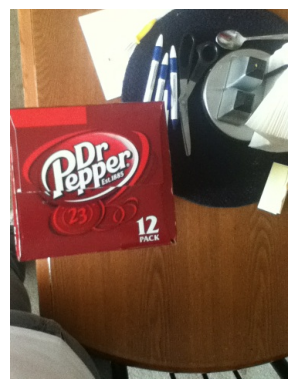

In [4]:
# Show one image

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(images[90])

plt.imshow(img)
plt.axis("off")

In [5]:
# Load and explore annotations

# Unzip and load data

from pathlib import Path
import zipfile
import os

ANN_ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/NN Lab3/Data/Annotations.zip"
ANN_OUT_DIR = "/content/vizwiz_annotations"

# clean + recreate
!rm -rf "$ANN_OUT_DIR"
!mkdir -p "$ANN_OUT_DIR"

with zipfile.ZipFile(ANN_ZIP_PATH, "r") as z:
    z.extractall(ANN_OUT_DIR)

print("Extracted to:", ANN_OUT_DIR)
print("Files:")
for p in Path(ANN_OUT_DIR).rglob("*"):
    if p.is_file():
        print(p)

Extracted to: /content/vizwiz_annotations
Files:
/content/vizwiz_annotations/test.json
/content/vizwiz_annotations/train.json
/content/vizwiz_annotations/val.json


In [6]:
from pathlib import Path

ann_dir = Path(ANN_OUT_DIR)
json_files = list(ann_dir.rglob("*.json"))

print("JSON files found:")
for f in json_files:
    print(f)

JSON files found:
/content/vizwiz_annotations/test.json
/content/vizwiz_annotations/train.json
/content/vizwiz_annotations/val.json


In [7]:
import json

train_json = [f for f in json_files if "train" in f.name.lower()][0]

with open(train_json, "r") as f:
    train_annotations = json.load(f)

print("Type:", type(train_annotations))
print("Number of samples:", len(train_annotations))
print("\nFirst sample:")
train_annotations[0]

Type: <class 'list'>
Number of samples: 20523

First sample:


{'image': 'VizWiz_train_00000000.jpg',
 'question': "What's the name of this product?",
 'answers': [{'answer_confidence': 'yes', 'answer': 'basil leaves'},
  {'answer_confidence': 'yes', 'answer': 'basil leaves'},
  {'answer_confidence': 'yes', 'answer': 'basil'},
  {'answer_confidence': 'yes', 'answer': 'basil'},
  {'answer_confidence': 'yes', 'answer': 'basil leaves'},
  {'answer_confidence': 'yes', 'answer': 'basil leaves'},
  {'answer_confidence': 'yes', 'answer': 'basil leaves'},
  {'answer_confidence': 'yes', 'answer': 'basil leaves'},
  {'answer_confidence': 'yes', 'answer': 'basil leaves'},
  {'answer_confidence': 'yes', 'answer': 'basil'}],
 'answer_type': 'other',
 'answerable': 1}

In [8]:
sample = train_annotations[0]

print("Keys:")
print(sample.keys())

for k, v in sample.items():
    print(f"\n{k}:")
    print(v)

Keys:
dict_keys(['image', 'question', 'answers', 'answer_type', 'answerable'])

image:
VizWiz_train_00000000.jpg

question:
What's the name of this product?

answers:
[{'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil'}, {'answer_confidence': 'yes', 'answer': 'basil'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil leaves'}, {'answer_confidence': 'yes', 'answer': 'basil'}]

answer_type:
other

answerable:
1


In [11]:
import pandas as pd

df = pd.DataFrame(train_annotations)
df.head(3)

,image,question,answers,answer_type,answerable
0,VizWiz_train_00000000.jpg,What's the name of this product?,"[{'answer_confidence': 'yes', 'answer': 'basil...",other,1
1,VizWiz_train_00000001.jpg,Can you tell me what is in this can please?,"[{'answer_confidence': 'yes', 'answer': 'soda'...",other,1
2,VizWiz_train_00000002.jpg,Is this enchilada sauce or is this tomatoes? ...,"[{'answer_confidence': 'yes', 'answer': 'these...",other,1


In [15]:
from pathlib import Path

image_dir = Path("/content/train_small")

df["image_path"] = df["image"].apply(lambda x: image_dir / x)

df.head(5)

,image,question,answers,answer_type,answerable,image_path,majority_answer
0,VizWiz_train_00000000.jpg,What's the name of this product?,"[{'answer_confidence': 'yes', 'answer': 'basil...",other,1,/content/train_small/VizWiz_train_00000000.jpg,basil leaves
1,VizWiz_train_00000001.jpg,Can you tell me what is in this can please?,"[{'answer_confidence': 'yes', 'answer': 'soda'...",other,1,/content/train_small/VizWiz_train_00000001.jpg,coca cola
2,VizWiz_train_00000002.jpg,Is this enchilada sauce or is this tomatoes? ...,"[{'answer_confidence': 'yes', 'answer': 'these...",other,1,/content/train_small/VizWiz_train_00000002.jpg,tomatoes
3,VizWiz_train_00000003.jpg,What is the captcha on this screenshot?,"[{'answer_confidence': 'yes', 'answer': 't36m'...",other,1,/content/train_small/VizWiz_train_00000003.jpg,t36m
4,VizWiz_train_00000004.jpg,What is this item?,"[{'answer_confidence': 'yes', 'answer': 'solar...",other,1,/content/train_small/VizWiz_train_00000004.jpg,solar garden light


In [13]:
from collections import Counter

def get_majority_answer(ans_list):
    answers = [a["answer"] for a in ans_list]
    return Counter(answers).most_common(1)[0][0]

df["majority_answer"] = df["answers"].apply(get_majority_answer)

df[["question","majority_answer"]].head()

,question,majority_answer
0,What's the name of this product?,basil leaves
1,Can you tell me what is in this can please?,coca cola
2,Is this enchilada sauce or is this tomatoes? ...,tomatoes
3,What is the captcha on this screenshot?,t36m
4,What is this item?,solar garden light


In [16]:
df["answerable"].value_counts()

,count
answerable,
1,14991
0,5532


## Run Model

In [ ]:
# Create README.md
readme_content = """# NN Lab 3: Neural Network Project

A comprehensive neural network project for Lab 3.

## Project Structure

```
nn-lab3/
├── notebooks/
│   └── lab3.ipynb          # Main Jupyter notebook
├── src/
│   ├── dataset.py          # Dataset handling module
│   ├── model.py            # Neural network model definition
│   ├── train.py            # Training script
│   └── utils.py            # Utility functions
├── requirements.txt        # Project dependencies
├── .gitignore             # Git ignore rules
└── README.md              # This file
```

## Installation

1. Clone the repository:
```bash
git clone https://github.com/datamoritz/nn-lab3.git
cd nn-lab3
```

2. Create a virtual environment:
```bash
python -m venv venv
source venv/bin/activate  # On Windows: venv\\Scripts\\activate
```

3. Install dependencies:
```bash
pip install -r requirements.txt
```

## Usage

Start the Jupyter notebook:
```bash
jupyter notebook notebooks/lab3.ipynb
```

## Requirements

- Python 3.8+
- PyTorch
- NumPy
- Pandas
- Matplotlib
- scikit-learn

## Author

Moritz Knodler

## License

MIT
"""

readme_path = project_root / 'README.md'
with open(readme_path, 'w') as f:
    f.write(readme_content)

print("✓ README.md created successfully!")

## Create README File

In [ ]:
# Create .gitignore
gitignore_content = """# Python
__pycache__/
*.py[cod]
*$py.class
*.so
.Python
build/
develop-eggs/
dist/
downloads/
eggs/
.eggs/
lib/
lib64/
parts/
sdist/
var/
wheels/
*.egg-info/
.installed.cfg
*.egg

# Virtual environments
venv/
ENV/
env/
.venv

# IDE
.vscode/
.idea/
*.swp
*.swo
*~
.DS_Store

# Jupyter
.ipynb_checkpoints/
*.ipynb_checkpoints

# Data and models
data/
models/
*.pkl
*.pth
*.pt

# Logs
*.log
"""

gitignore_path = project_root / '.gitignore'
with open(gitignore_path, 'w') as f:
    f.write(gitignore_content)

print("✓ .gitignore created successfully!")

## Create .gitignore File

In [ ]:
# Create requirements.txt
requirements_content = """torch>=2.0.0
numpy>=1.21.0
pandas>=1.3.0
matplotlib>=3.4.0
scikit-learn>=0.24.0
jupyter>=1.0.0
"""

requirements_path = project_root / 'requirements.txt'
with open(requirements_path, 'w') as f:
    f.write(requirements_content)

print("✓ requirements.txt created successfully!")
print("\nDependencies:")
print(requirements_content)

## Create Requirements File

In [ ]:
# Create Python module files with placeholder content
modules = {
    'dataset.py': '''"""Dataset module for Lab 3."""

class Dataset:
    """Placeholder class for dataset handling."""
    pass
''',
    'model.py': '''"""Model module for Lab 3."""

class NeuralNetwork:
    """Placeholder class for neural network model."""
    pass
''',
    'train.py': '''"""Training module for Lab 3."""

def train():
    """Placeholder training function."""
    pass
''',
    'utils.py': '''"""Utility functions for Lab 3."""

def helper_function():
    """Placeholder utility function."""
    pass
'''
}

for filename, content in modules.items():
    filepath = project_root / 'src' / filename
    with open(filepath, 'w') as f:
        f.write(content)
    print(f"✓ Created {filename}")

print("Python modules created successfully!")

## Generate Python Module Files

In [ ]:
# Define the project root directory
project_root = Path.cwd()

# Create directory structure
os.makedirs(project_root / 'notebooks', exist_ok=True)
os.makedirs(project_root / 'src', exist_ok=True)

print("✓ Directory structure created successfully!")
print(f"Project root: {project_root}")

## Create Project Directory Structure

In [ ]:
import os
import subprocess
from pathlib import Path

## Import Required Libraries

# Lab 3: Neural Network Project

This notebook sets up the project structure for NN Lab 3 and initializes the Git repository.